# WinePredict

## Install and set-up

In [1]:
!python -m pip install -q -U git+https://github.com/chris-lawrence-cd/winepredict.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 14.9 MB/s eta 0:00:00


In [2]:
# Import necessary functions from the library
import statsmodels
from winepredict.data_processing import preprocess_and_analyze_data, process_fred_data
from winepredict.model_training import train_and_evaluate_models, tune_and_evaluate_catboost
from winepredict.model_evaluation import evaluate_model, cross_validate_model
from winepredict.visualization import plot_actual_vs_predicted, visualize_residuals, plot_feature_importance
from winepredict import info

import numpy as np
import random
from sklearn.model_selection import train_test_split

# Define FRED API key
api_key = 'db26981c344747951316ccd9c7d01f0d'

# Set seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

In [3]:
# Print library information
info()


██╗    ██╗██╗███╗   ██╗███████╗    ██████╗ ██████╗ ███████╗██████╗ ██╗ ██████╗████████╗
██║    ██║██║████╗  ██║██╔════╝    ██╔══██╗██╔══██╗██╔════╝██╔══██╗██║██╔════╝╚══██╔══╝
██║ █╗ ██║██║██╔██╗ ██║█████╗      ██████╔╝██████╔╝█████╗  ██║  ██║██║██║        ██║   
██║███╗██║██║██║╚██╗██║██╔══╝      ██╔═══╝ ██╔══██╗██╔══╝  ██║  ██║██║██║        ██║   
╚███╔███╔╝██║██║ ╚████║███████╗    ██║     ██║  ██║███████╗██████╔╝██║╚██████╗   ██║   
 ╚══╝╚══╝ ╚═╝╚═╝  ╚═══╝╚══════╝    ╚═╝     ╚═╝  ╚═╝╚══════╝╚═════╝ ╚═╝ ╚═════╝   ╚═╝   

Welcome to the WinePredict library!
This library provides tools for predicting wine prices using various machine learning models.
It includes functions for data processing, model training, evaluation, and visualization.
Use this library to build, train, and evaluate models to forecast wine prices based on economic indicators.


## Run and evaluate multiple models

In [4]:
# Step 1: Download and process FRED data
process_fred_data(api_key)

# Step 2: Preprocess and analyze data
file_path = 'FRED_Data.xlsx'
scaled_df = preprocess_and_analyze_data(file_path, output_file='correlation_matrix.png')

# Step 3: Train and evaluate multiple models
results_df = train_and_evaluate_models(scaled_df)

Data downloaded, filtered, resampled to monthly frequency, and saved to FRED_Data.xlsx.


In [5]:
# Step 4: Tune and evaluate CatBoost model
X = scaled_df.drop(['Average Wine Price'], axis=1)
y = scaled_df['Average Wine Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=1)

# Call the function once and use the results
catboost_results = tune_and_evaluate_catboost(X_train, y_train, X_test, y_test)

Starting grid search fitting...
Grid search fitting completed successfully.
Result dictionary: {'Best Parameters': {'depth': 4, 'iterations': 100, 'learning_rate': 0.1}, 'Best Estimator': <catboost.core.CatBoostRegressor object at 0x783bde4592d0>, 'R²': 0.8982456406747831, 'RMSE': 0.9051546918488684, 'MAE': 0.5800287125910712, 'Feature Importances':                                  Feature Id  Importances
0                      Producer Price Index    27.832928
1         Personal Consumption Expenditures    14.924653
2                         Money Supply (M1)    14.889725
3                    Total Nonfarm Payrolls     7.510228
4                              Retail Sales     6.372648
5                         Unemployment Rate     6.306500
6                Consumer Price Index (CPI)     5.923121
7               Industrial Production Index     2.959230
8                        Federal Funds Rate     2.599412
9                            Housing Starts     2.433281
10                Con

## Visualize

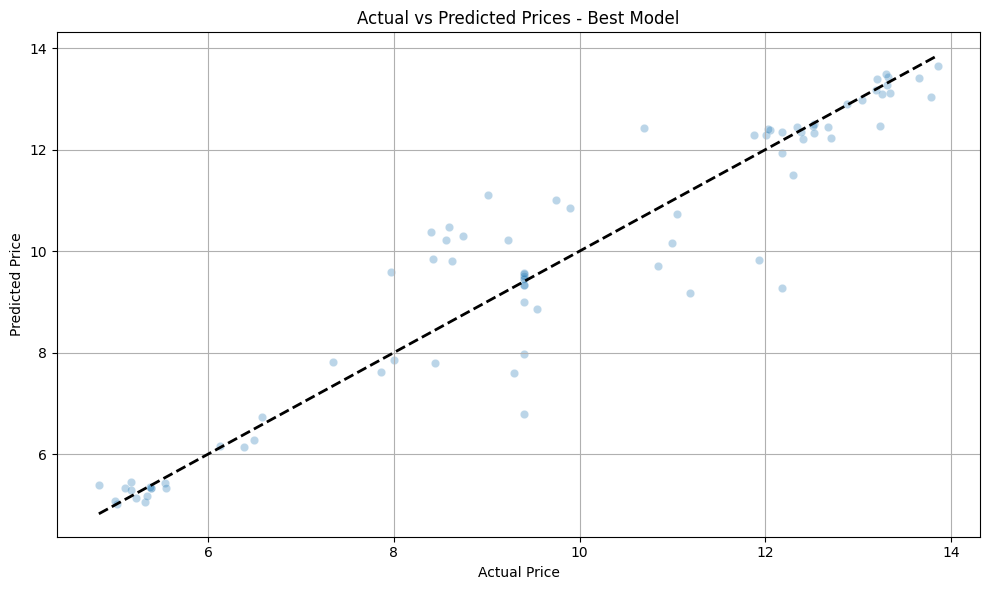

In [6]:
# Access the best model from the results
best_catboost = catboost_results['Best Estimator']

# Now you can use best_catboost to make predictions
plot_actual_vs_predicted(y_test, best_catboost.predict(X_test))

In [7]:
# Evaluate the best model on training and testing data
evaluate_model(best_catboost, X_train, X_test, y_train, y_test)

Train Adjusted R²: 0.96912, Test Adjusted R²: 0.86822
Train RMSE: 0.50269, Test RMSE: 0.90515
Train MAE: 0.35764, Test MAE: 0.58003


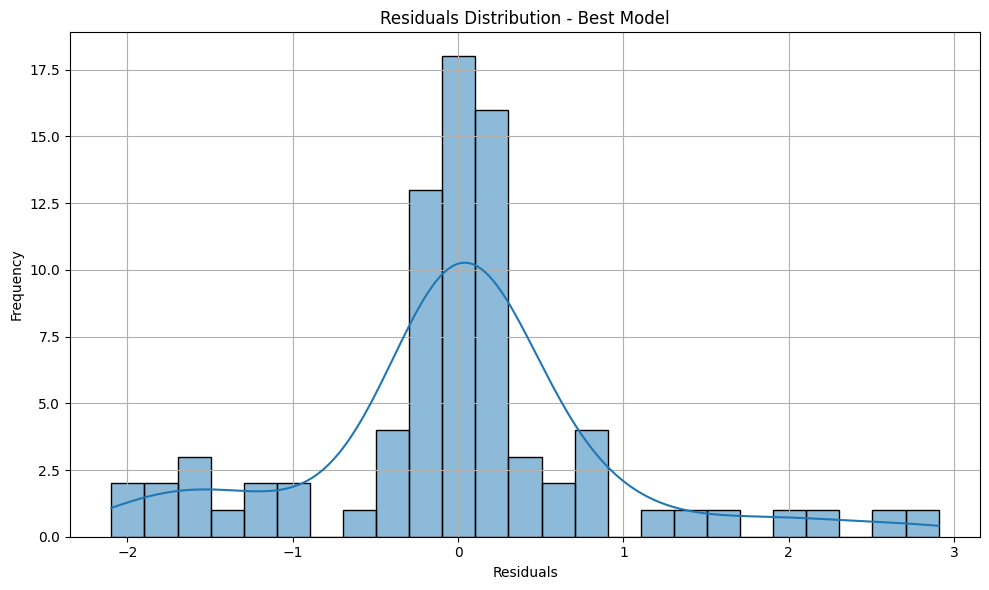

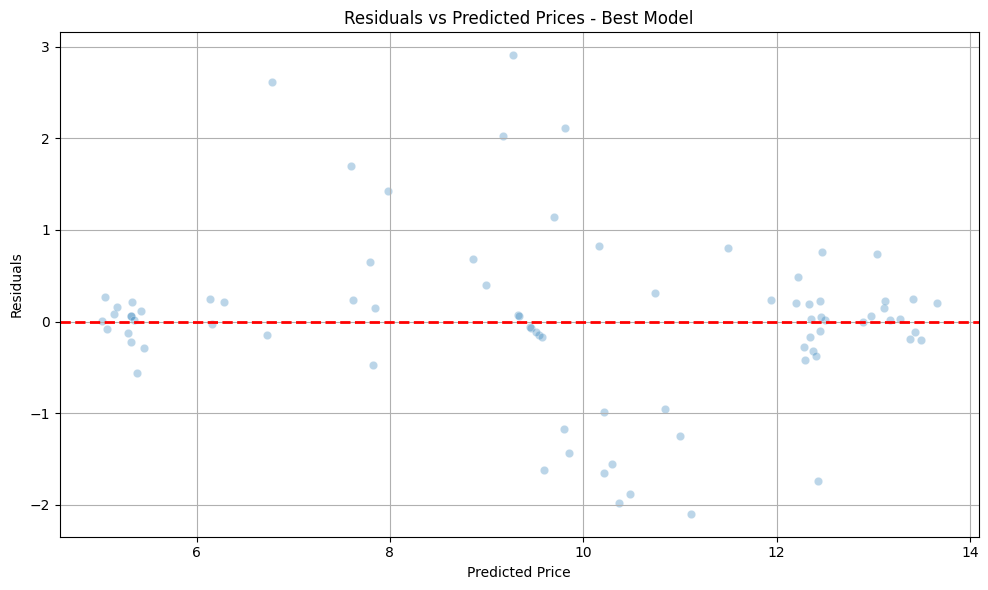

In [8]:
# Visualize residuals
visualize_residuals(y_test, best_catboost.predict(X_test))

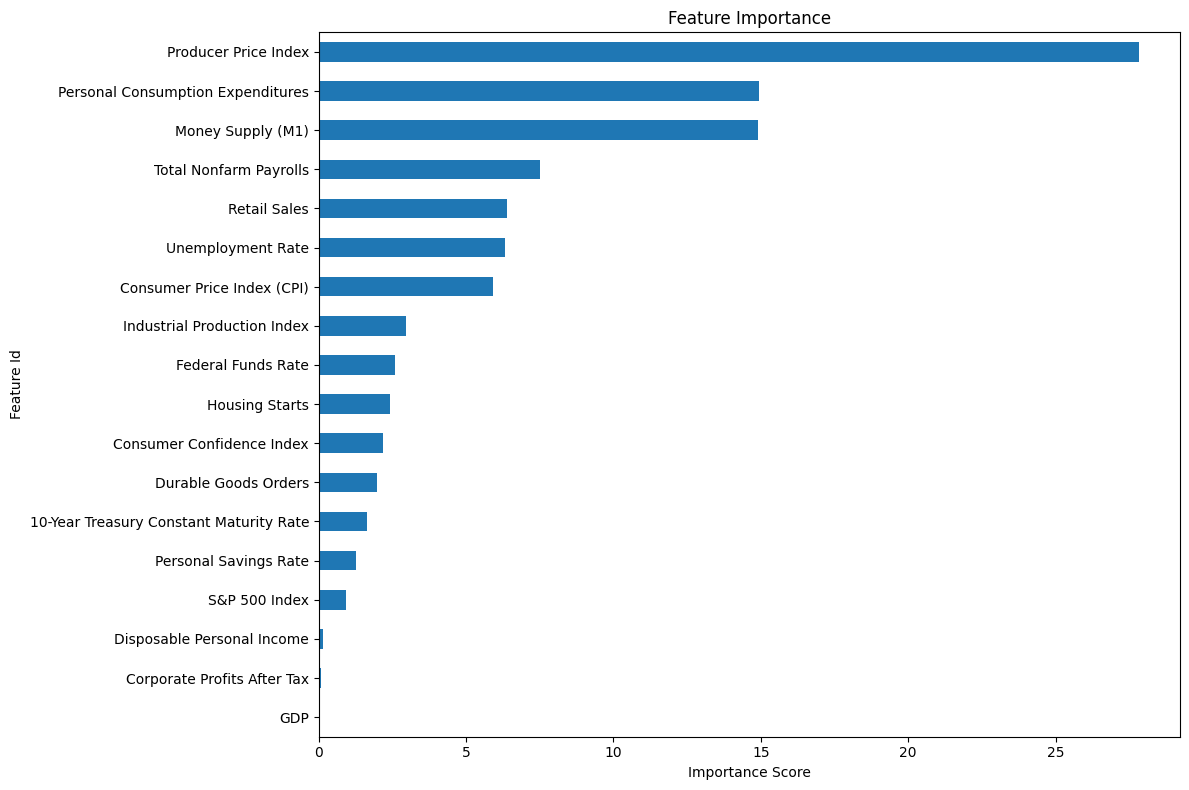

In [13]:
# Convert feature importances to a Series
feature_importance_series = catboost_results['Feature Importances'].set_index('Feature Id')['Importances']

# Plot feature importance
plot_feature_importance(feature_importance_series)

## Zip and download files

In [ ]:
import zipfile
import os

# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

output_dir = "/content/"
zip_file_path = "/content/output.zip"

def zipdir(path, ziph, exclude_dirs=[]):
    # ziph is zipfile handle
    for root, dirs, files in os.walk(path):
        # Exclude directories in exclude_dirs
        dirs[:] = [d for d in dirs if d not in exclude_dirs]
        for file in files:
            absfn = os.path.join(root, file)
            relfn = os.path.relpath(absfn, path)
            ziph.write(absfn, relfn)

if IN_COLAB:
    # If in Colab, zip and download the file
    from google.colab import files
    with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        zipdir(output_dir, zipf, exclude_dirs=['sample_data'])
    files.download(zip_file_path)
    print("Output files have been zipped and downloaded.")
else:
    # If running locally, just create the zip file
    with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        zipdir(output_dir, zipf, exclude_dirs=['sample_data'])
    print(f"Output files have been zipped and saved to {zip_file_path}")
